# Приклади роз'язання 
Візьмемо для простого прикладу простенький граф бамбук:

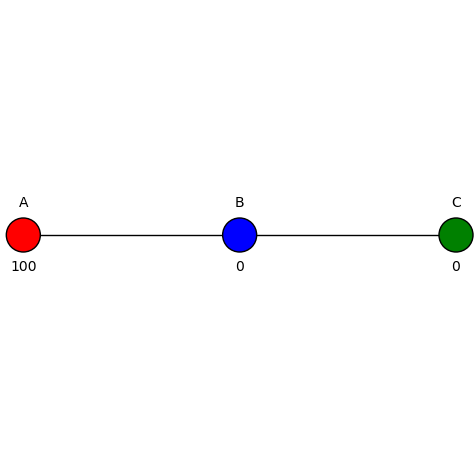

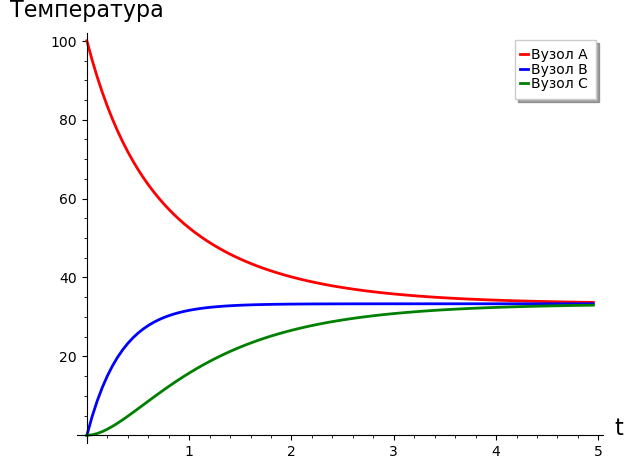

In [24]:
u0 = vector(QQ, [100, 0, 0])

G = graphs.PathGraph(3)
names = {0: "A", 1: "B", 2: "C"}
values = {0: f"{u0[0]}", 1: f"{u0[1]}", 2: f"{u0[2]}"}
labels = {i: f"{names[i]}\n\n\n\n{values[i]}" for i in range(3)}
colors = {
    'red': [0],
    'blue': [1],
    'green': [2]
}
show(G.plot(vertex_size=600, vertex_labels=labels, vertex_color=colors))

A = matrix(QQ, G.adjacency_matrix())

degrees = [G.degree(v) for v in G.vertices()]
D = diagonal_matrix(QQ, degrees)

L = D - A

Lambda, Q = L.diagonalization()

def u(t):
    exp_Lambda = diagonal_matrix([exp(-Lambda[i,i] * t) for i in range(Lambda.nrows())])
    return Q * exp_Lambda * Q.inverse() * u0

times = srange(0, 5, 0.05)

vals0 = []
vals1 = []
vals2 = []

for t in times:
    ut = u(t).n()
    vals0.append(ut[0])
    vals1.append(ut[1])
    vals2.append(ut[2])

p = line(list(zip(times, vals0)), color="red", legend_label="Вузол A", thickness=2)
p += line(list(zip(times, vals1)), color="blue", legend_label="Вузол B", thickness=2)
p += line(list(zip(times, vals2)), color="green", legend_label="Вузол C", thickness=2)

p.axes_labels(["t", "Температура"])
show(p)

Тут зображено те, як на графі змінюється температура за $5$ секунд, при початкових умовах де в нас дві вершини мають температуру $0$, та одна вершина нагріта аж до $100$.

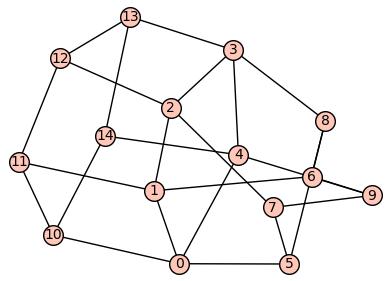

TypeError: '_cython_3_0_12.cython_function_or_method' object is not subscriptable

In [27]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

u1 = vector(RDF, [34, 12, 88, 5, 47, 91, 23, 66, 74, 19, 12, 44, 52, 69, 38])

data = [(0, 10), (1, 11), (2, 12), (3, 13), (4, 14), (10, 11), (11, 12), (12, 13), (13, 14), (10, 14)]
H1 = graphs.PetersenGraph()
H2 = Graph(data)
U = H2.union(H1)
U.show()

A = matrix(RDF, U.adjacency_matrix())

degrees = [U.degree(v) for v in U.vertices()]
D = diagonal_matrix(RDF, degrees)

L = D - A

D_mat, Q = L.eigenmatrix_right()

Q_inv = Q.inverse()

def u(t):
    # D_mat[i,i] — це наші власні значення
    exp_Lambda = diagonal_matrix(RDF, [exp(-D_mat[i,i] * t) for i in range(D_mat.nrows())])
    return Q * exp_Lambda * Q_inv * u1

times = srange(0, 5, 0.05)

vals = [[] for _ in range(len(u1))]

for t in times:
    ut = u(t).n()
    for i in range(len(u1)):
        vals[i].append(ut[0])

cmap = plt.get_cmap('coolwarm')
norm = colors.Normalize(vmin=min(vector[1]), vmax=max(vector[1]))

p = Graphics()
for i in range(len(u1)): 
    p += line(list(zip(times, vals[i])), color="red", legend_label="Вузол A", thickness=2)

p.axes_labels(["t", "Температура"])
show(p)